# 02 · 你的第一個神經網路

有了 Tensor 與 autograd，這堂課用 `nn.Module` 把它們組成一個真正的**神經網路**。我們搭一個小分類器，先看它「還沒訓練」時亂猜的樣子——下一課再教怎麼訓練它。

## 學習目標

- 用 `nn.Module` 定義網路、`nn.Linear` 當全連接層
- 理解**激活函數**（ReLU）為什麼不可少
- 跑一次 forward，數一數網路有幾個參數

## 1. 一份非線性的資料

`make_moons` 造兩個交纏的半月——一條直線分不開，正好需要神經網路。

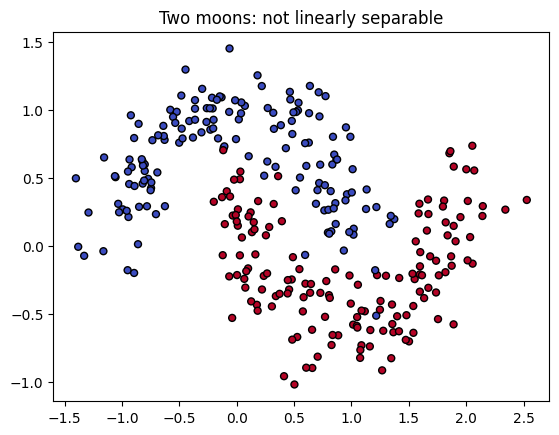

In [1]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

torch.manual_seed(0)
X_np, y_np = make_moons(n_samples=300, noise=0.2, random_state=0)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap="coolwarm", edgecolor="k", s=25)
plt.title("Two moons: not linearly separable"); plt.show()

## 2. 定義網路

`nn.Module` 是所有網路的基底。慣例：在 `__init__` 裡宣告各層，在 `forward` 裡描述資料怎麼流過。

In [2]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 16)   # 輸入 2 維 → 隱藏 16
        self.fc2 = nn.Linear(16, 16)  # 隱藏 → 隱藏
        self.fc3 = nn.Linear(16, 2)   # 隱藏 → 2 類

    def forward(self, x):
        x = torch.relu(self.fc1(x))   # 激活函數：引入非線性
        x = torch.relu(self.fc2(x))
        return self.fc3(x)            # 輸出 logits（還沒 softmax）

model = MLP()
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\n總參數量：{n_params}")

MLP(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=2, bias=True)
)

總參數量：354


## 3. 為什麼需要激活函數？

如果把 `torch.relu` 拿掉，幾層 `nn.Linear` 疊起來在數學上**仍只是一條直線**（線性的線性還是線性）——再多層也分不開半月。**ReLU** 這類非線性激活，才讓網路能彎曲決策邊界、學到複雜模式。

## 4. 跑一次 forward

還沒訓練的網路，權重是隨機的，預測自然是亂猜。

In [3]:
logits = model(X)                       # forward：一次餵全部資料
pred = logits.argmax(dim=1)             # 取機率最大的類別
acc = (pred == y).float().mean()
print("輸出 logits 形狀:", logits.shape)
print(f"未訓練的準確率：{acc.item():.1%}  (約 50%，等於亂猜)")

輸出 logits 形狀: torch.Size([300, 2])
未訓練的準確率：50.0%  (約 50%，等於亂猜)


## 小結

- 網路繼承 `nn.Module`：`__init__` 宣告層、`forward` 描述資料流。
- `nn.Linear` 是全連接層；**激活函數（ReLU）** 提供非線性，缺它網路退化成一條直線。
- forward 出來的是 **logits**；未訓練時準確率約等於亂猜。

## 練習

1. 多加一層 `nn.Linear(16, 16)` 與對應的 ReLU，參數量變多少？
2. 把 `forward` 裡的 `torch.relu` 全部移除，未訓練準確率有變嗎？（下一課訓練後會看出差異）

下一課，寫出**訓練迴圈**，讓這個網路真的學會分半月。